# Nanopore Signal Processing and DTW Analysis

This notebook performs comprehensive signal processing on nanopore translocation data, including filtering, normalization, Dynamic Time Warping (DTW) alignment, barycenter calculation, and data export. The analysis is conducted for two directions of translocation.

###  Import Libraries and Functions

Import all required Python libraries for data processing, signal analysis, machine learning, and visualization. Also import custom functions from main_functions.py.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tslearn.preprocessing import TimeSeriesResampler
from Process_Functions import Bessel_Filter, Down_sampling, normalized_translocation, interplotation, Draw_Plot, normalized_time_axis, normalized_delta
from scipy.ndimage import gaussian_filter1d
import os
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from main_functions import *

In [2]:
%load_ext autoreload
%autoreload 2
plt.rcParams['figure.dpi'] = 200

## 1. Setup and Data Processing

This section handles the initial setup, including importing necessary libraries, enabling auto-reload for development, defining file paths, and processing the raw nanopore data for both translocation directions.

###  Define Data Paths

Set up the file paths for the raw data directories and specific files for both translocation directions.

In [3]:
current_dir=os.getcwd()
dir_120='data_120'
dir_final='data_final'
dir_new='data_new'
direction_1='direction_1.xlsx'
direction_2='direction_2.xlsx'

### Process Direction 1 Data

Load and process the raw signal data for direction 1 translocation, applying filtering, normalization, and length constraints.

In [4]:
time_normalized_data_1,selected_signal_index_1=Signal_Processing(os.path.join(current_dir,dir_new,direction_1),upper_lim=2000,lower_lim=100,
                                        cut_off_frequency=5,normalization_method='standard',smooth=False,threshold=60)

### Process Direction 2 Data

Load and process the raw signal data for direction 2 translocation, applying the same filtering and normalization as direction 1.

In [5]:
time_normalized_data_2,selected_signal_index_2=Signal_Processing(os.path.join(current_dir,dir_new,direction_2),upper_lim=2000,lower_lim=100,
                                        cut_off_frequency=5,normalization_method='standard',smooth=False,threshold=60)

In [6]:
print(len(time_normalized_data_1),len(time_normalized_data_2))

77 55


## 2. DTW Alignment

This section performs Dynamic Time Warping (DTW) to align the time-normalized signals, allowing comparison of signals with different temporal characteristics. Outliers are first removed, then alignment is performed for each direction.

### Remove Outlier Signals

Filter out signals with specific indices that are considered outliers based on prior analysis.

In [7]:
target_numbers_2 =[102, 79, 72, 25,9]
target_numbers_1 = [29, 33, 66, 174]
indices_to_remove_1 = [i for i, num in enumerate(selected_signal_index_1) if num in target_numbers_1]
indices_to_remove_2 = [i for i, num in enumerate(selected_signal_index_2) if num in target_numbers_2]
for index in sorted(indices_to_remove_1, reverse=True):
    del selected_signal_index_1[index]
    del time_normalized_data_1[index]
    
for index in sorted(indices_to_remove_2, reverse=True):
    del selected_signal_index_2[index]
    del time_normalized_data_2[index]


### Visualize Signal Length Distribution



Text(0, 0.5, 'counts')

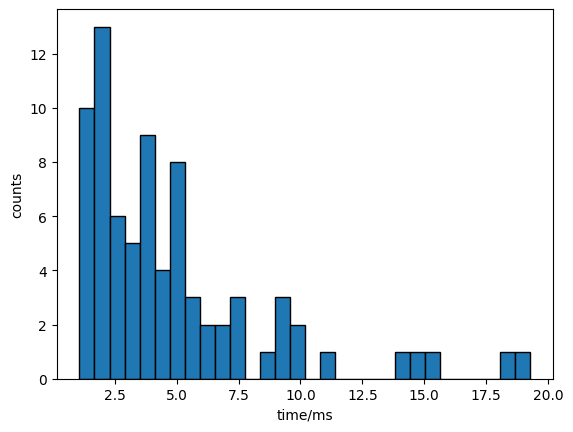

In [8]:
plt.rcParams['figure.dpi'] = 100
plt.hist([series.shape[0]/100 for series in time_normalized_data_1], bins=30,  edgecolor='black')
plt.xlabel('time/ms')
plt.ylabel('counts')

Text(0, 0.5, 'counts')

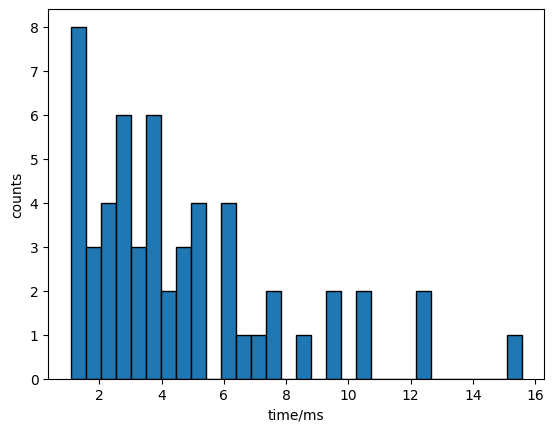

In [9]:
plt.hist([series.shape[0]/100 for series in time_normalized_data_2], bins=30,  edgecolor='black')
plt.xlabel('time/ms')
plt.ylabel('counts')

### DTW alignment and DTW distance visualization

DTW alignment and DTW distance calculation are performed in both Direction 1 and Direction 2. The signal with the least sum of normalized DTW distance is selected as the template sginal.

145


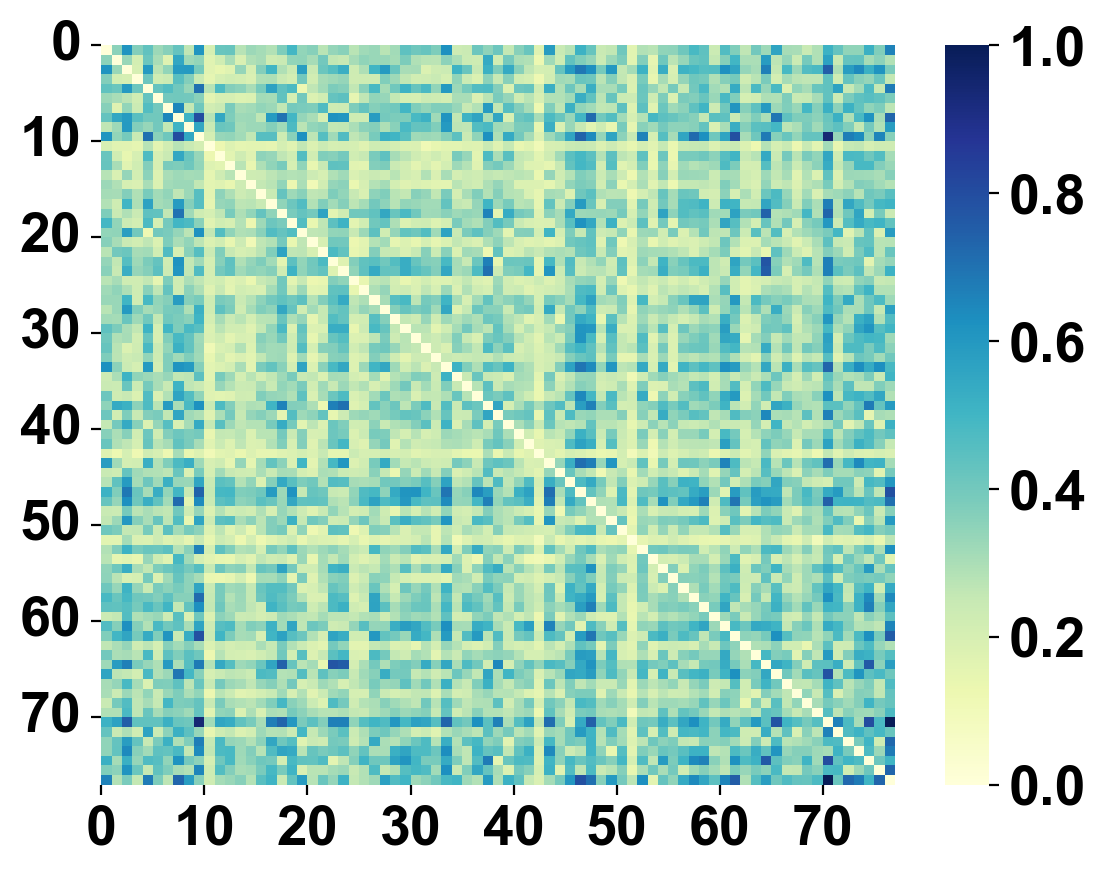

77 51
lowest distance is from(145, 180)


In [10]:
aligned_data_unique_1,_=dtw_alignment(time_normalized_data_1,signal_index=selected_signal_index_1,plot_series=True,
                                            plot_alignment=False,show_matrix=True,smooth=False,constraint="sakoe_chiba",
                                            sakoe_radius=100,target_path=None,inverse=False)

137


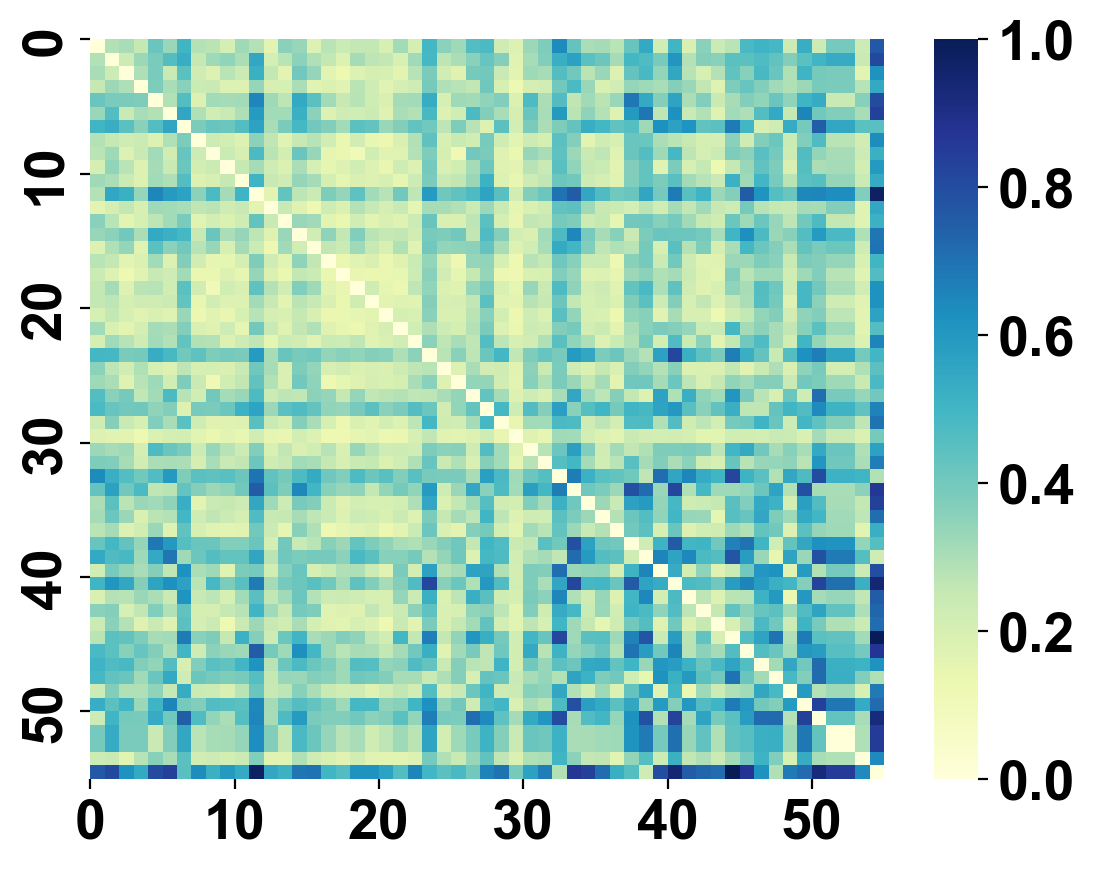

55 29
lowest distance is from(42, 100)


In [11]:
aligned_data_unique_2,_=dtw_alignment(time_normalized_data_2,signal_index=selected_signal_index_2,plot_series=True,
                                            plot_alignment=False, show_matrix=True,smooth=False,constraint="sakoe_chiba",
                                            sakoe_radius=0.01,target_path=None,inverse=False)

### Visualize DTW Aligned Data

Plot the DTW-aligned signals to see how the temporal alignment affects the signal shapes and allows for better comparison.

Draw the Plot

Text(0, 0.5, 'current')

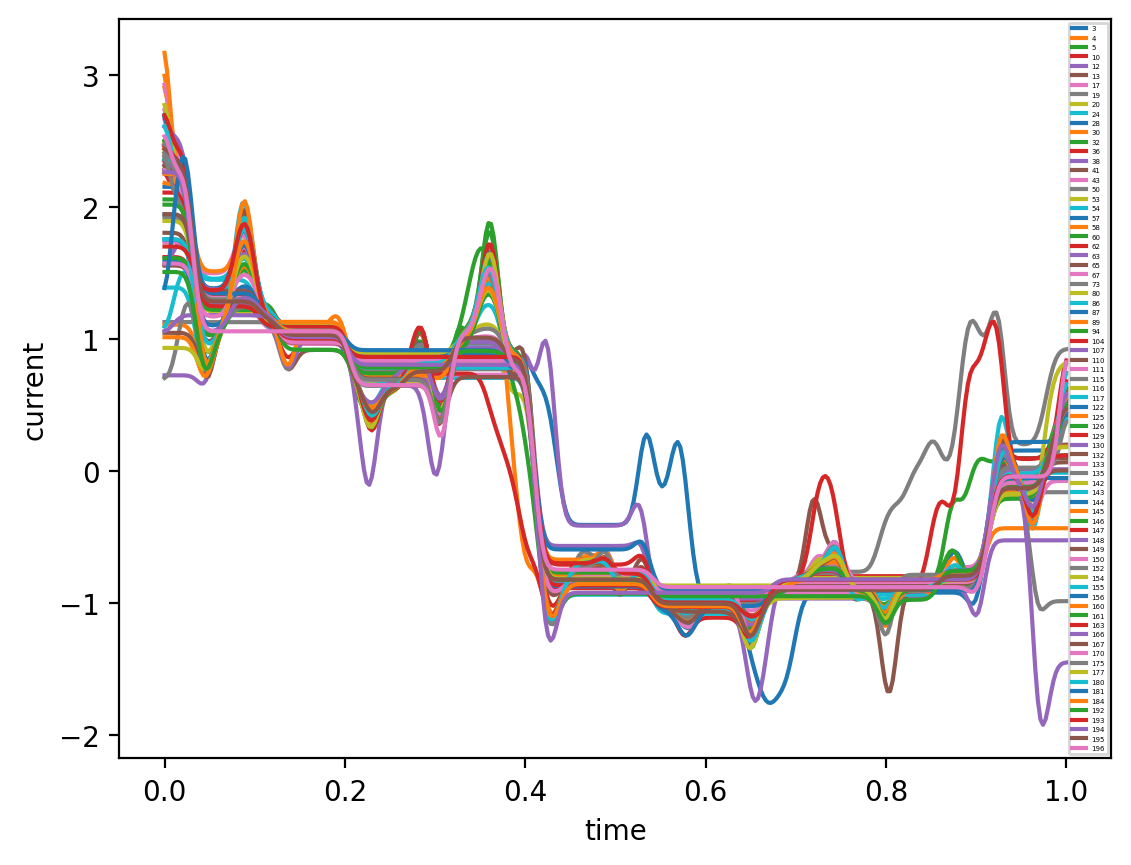

In [12]:

for index, series in enumerate(aligned_data_unique_1):
            
    plt.plot(series[0,:], gaussian_filter1d(series[1,:],sigma=2.5) ,label=str(selected_signal_index_1[index]))

plt.legend(fontsize=2.5)
plt.xlabel('time')
plt.ylabel('current')
#plt.show()

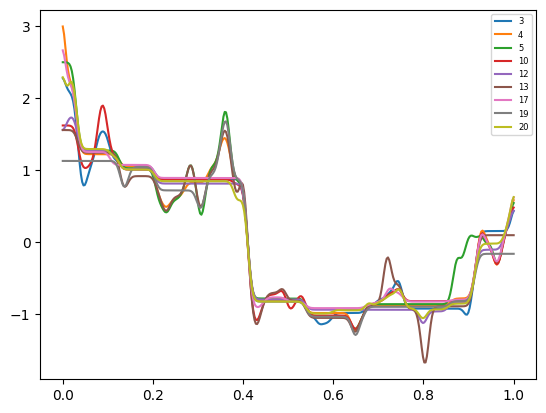

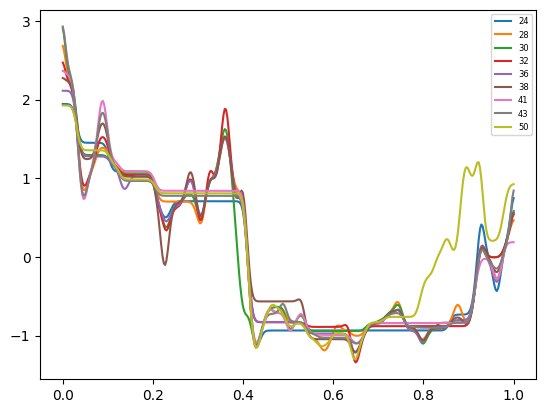

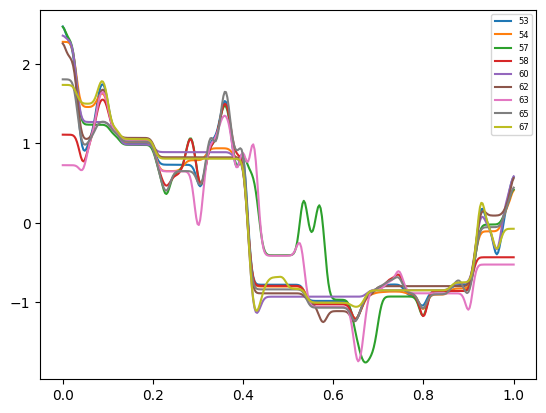

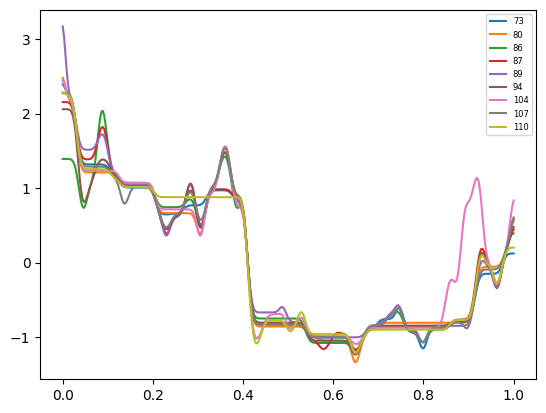

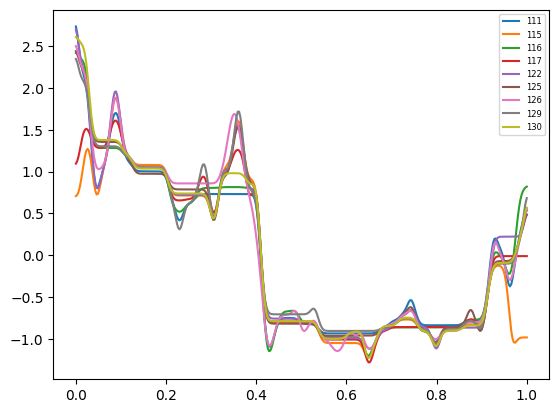

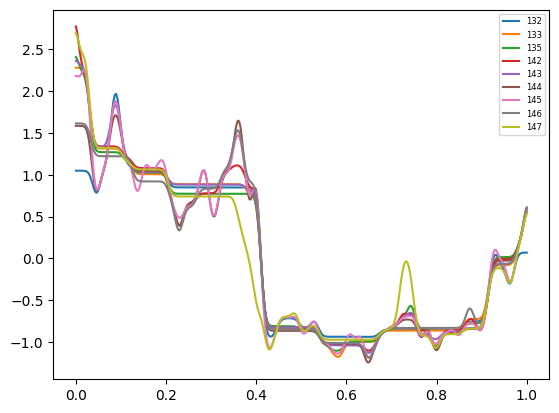

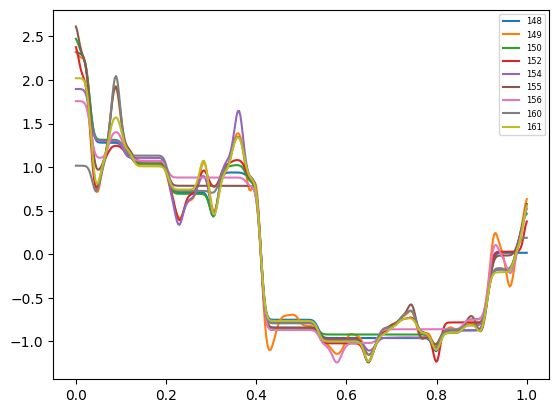

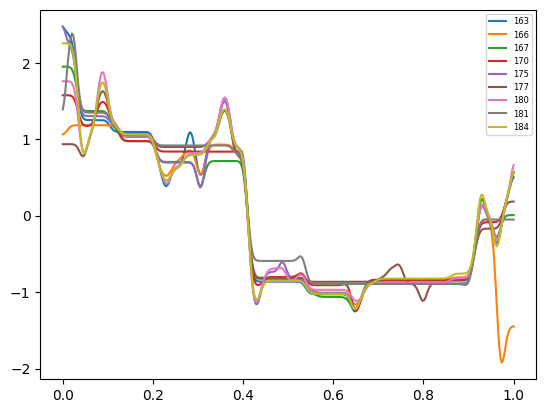

/tmp/ipykernel_2110290/3922220660.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=3)


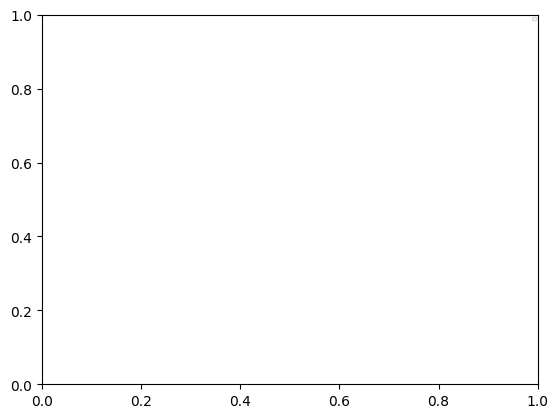

In [13]:
from cycler import cycler
plt.rcParams['figure.dpi'] = 100
num=9
num_groups = len(aligned_data_unique_1) // num

for group_idx in range(num_groups):
    start = group_idx * num
    end = (group_idx + 1) * num
    group_data = aligned_data_unique_1[start:end]
    group_index = selected_signal_index_1[start:end]
    

    for index, series in enumerate(group_data):
        x = series[0, :]
        y = gaussian_filter1d(series[1, :], sigma=2.5)

        plt.plot(x, y, label=str(group_index[index]))
    plt.legend(fontsize=6)
    plt.show()


remaining_start = num_groups * 15
remaining_data = aligned_data_unique_1[remaining_start:]
remaining_index = selected_signal_index_1[remaining_start:]
if remaining_data:
    for index, series in enumerate(remaining_data):
        x = series[0, :]
        y = gaussian_filter1d(series[1, :], sigma=2.5)
        plt.plot(x, y, label=str(group_index[index]))

plt.legend(fontsize=3)
plt.show()

## 3. Soft-DTW Barycenter Calculation

Traditional averaging fails for nanopore signals due to non-linear temporal stretching and varying sequence lengths. We use **Soft-DTW Barycenters** (the Fréchet Mean) to find the "representative" signal for a specific translocation direction. Unlike standard DTW, Soft-DTW is a differentiable loss function that considers all possible alignment paths. The "Barycenter" is the sequence $x$ that minimizes the sum of Soft-DTW distances: $\arg\min \sum \text{soft-DTW}(x, y_i)$.

The smoothing parameter $\gamma$ controls the trade-off between the sharpness of the alignment and the smoothness of the resulting average.

Text(0, 0.5, 'current')

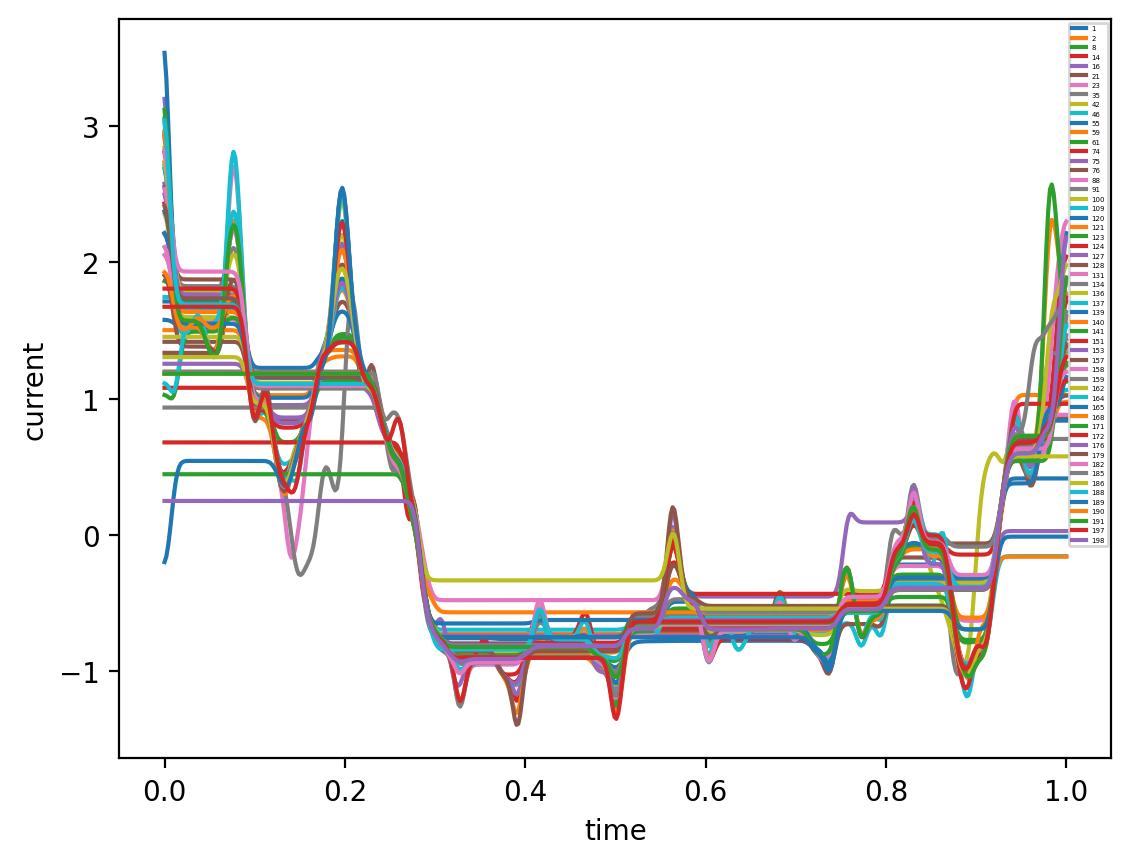

In [14]:
plt.rcParams['figure.dpi'] = 200
for index, series in enumerate(aligned_data_unique_2):
            
    plt.plot(series[0,:], gaussian_filter1d(series[1,:],sigma=2.5) ,label=str(selected_signal_index_2[index]))

plt.legend(fontsize=2.5)
plt.xlabel('time')
plt.ylabel('current')
#plt.show()

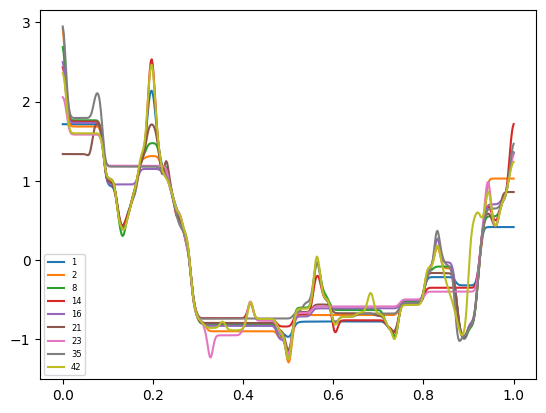

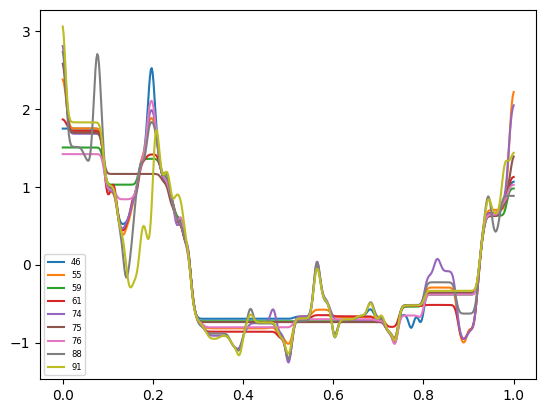

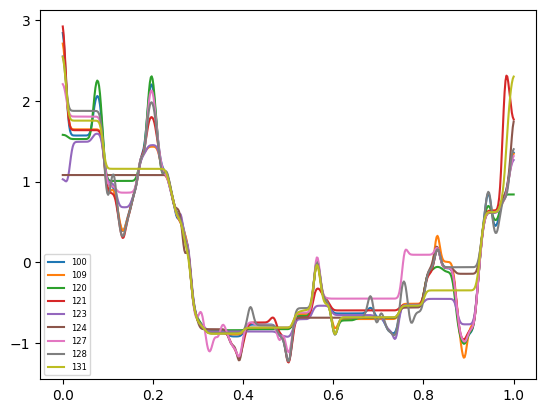

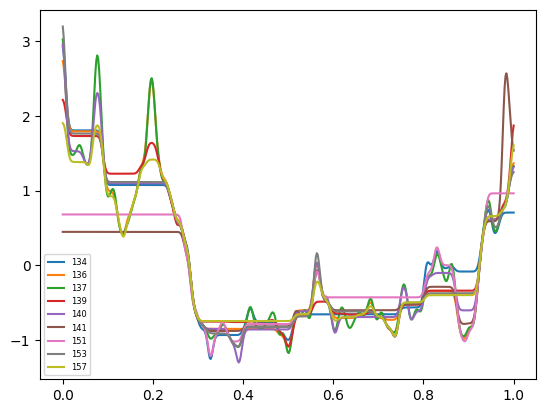

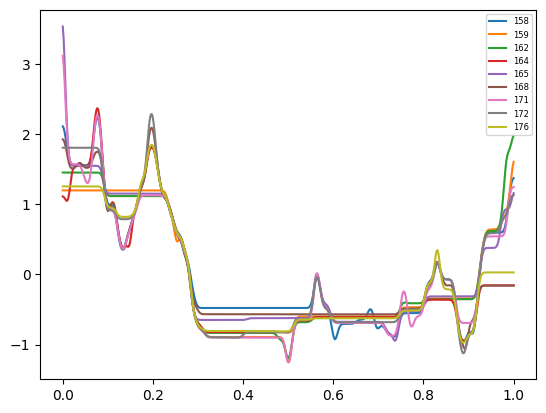

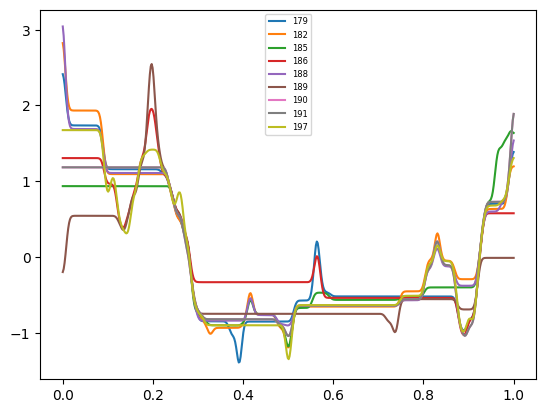

/tmp/ipykernel_2110290/724920739.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=3)


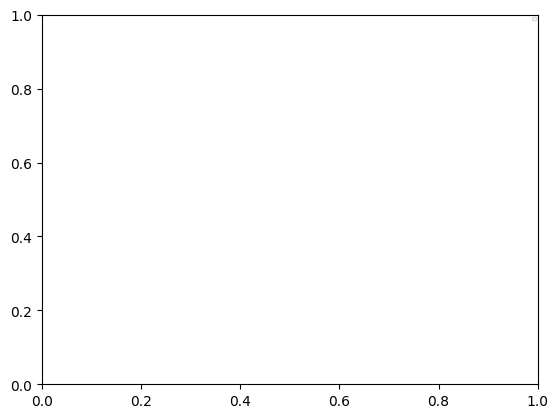

In [15]:
plt.rcParams['figure.dpi'] = 100
num=9
num_groups = len(aligned_data_unique_2) // num
for group_idx in range(num_groups):
    start = group_idx * num
    end = (group_idx + 1) * num
    group_data = aligned_data_unique_2[start:end]
    group_index = selected_signal_index_2[start:end]

    for index, series in enumerate(group_data):
        x = series[0, :]
        y = gaussian_filter1d(series[1, :], sigma=2.5)

        plt.plot(x, y, label=str(group_index[index]))
    plt.legend(fontsize=6)
    plt.show()

# 处理剩余不足 15 个的数据
remaining_start = num_groups * 15
remaining_data = aligned_data_unique_2[remaining_start:]
remaining_index = selected_signal_index_2[remaining_start:]
if remaining_data:
    for index, series in enumerate(remaining_data):
        x = series[0, :]
        y = gaussian_filter1d(series[1, :], sigma=2.5)
        plt.plot(x, y, label=str(group_index[index]))

plt.legend(fontsize=3)
plt.show()

In [16]:
import copy
def filter_arr(data):
    data_1=[]
    

    
    for arr in data:
        arr_1=copy.deepcopy(arr)
        arr_1[1,:]=gaussian_filter1d(arr[1,:],sigma=2.5)
        data_1.append(arr_1)
    return data_1
aligned_data_1_filtered=filter_arr(aligned_data_unique_1)
aligned_data_2_filtered=filter_arr(aligned_data_unique_2)

Barycenter Plot

In [17]:
def barycenter_process(data,target_length=500):
    data_current=[series.to_numpy().T[1,:] for series in data]
    _,barycenter,time_series=barycenter_plot([gaussian_filter1d(series,sigma=5) for series in data_current],target_length=target_length,
                                                                    gamma=0.5,max_iter=500)
    data_time=np.linspace(0,1,len(barycenter))
    data_standard_series=pd.DataFrame({'t':data_time,'i':barycenter.ravel()})
    _,average_signal=dtw_alignment(data,series_standard= data_standard_series)
    return average_signal

    

In [18]:
average_signal_1=barycenter_process(time_normalized_data_1,target_length=500)

/home/EJ/miniconda3/envs/dtw/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [19]:
average_signal_2=barycenter_process(time_normalized_data_2,target_length=500)

In [20]:
print(average_signal_1.shape)

(500,)


### Compare the Direction 1 Barycenter and flipped Direction 2 Barycenter

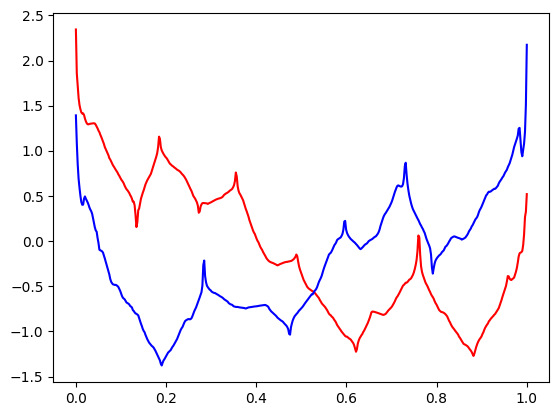

In [21]:
comparison_plot(series1=gaussian_filter1d(average_signal_1,sigma=0.5) ,series2=gaussian_filter1d(average_signal_2,sigma=0.5),flip=True)

### DDTW analysis and Peak-Valley analysis

In [ ]:
_,_,_ = ddtw_processing(average_signal_1, np.flip(average_signal_2), signal_weight = 0.5,
                    derivative_weight = 2, extrema_weight = 10, prominence_value = 0.05)

AttributeError: 'numpy.ndarray' object has no attribute 'flip'

### Export the barycenters to Excel files

In [23]:
average_signal_1_export=gaussian_filter1d(average_signal_1,sigma=2.5)
average_signal_2_export=np.flip(gaussian_filter1d(average_signal_2,sigma=2.5))
#average_signal=[average_signal_1_export,average_signal_2_export]
#export_data(average_signal,save_path=os.path.join('final_export_data','total_barycenter'),file_name='total_barycenter')



### Example signal after DTW alignment 

In [24]:
example_1= time_normalized_data_1[selected_signal_index_1.index(145)]
example_2= time_normalized_data_1[selected_signal_index_1.index(180)]

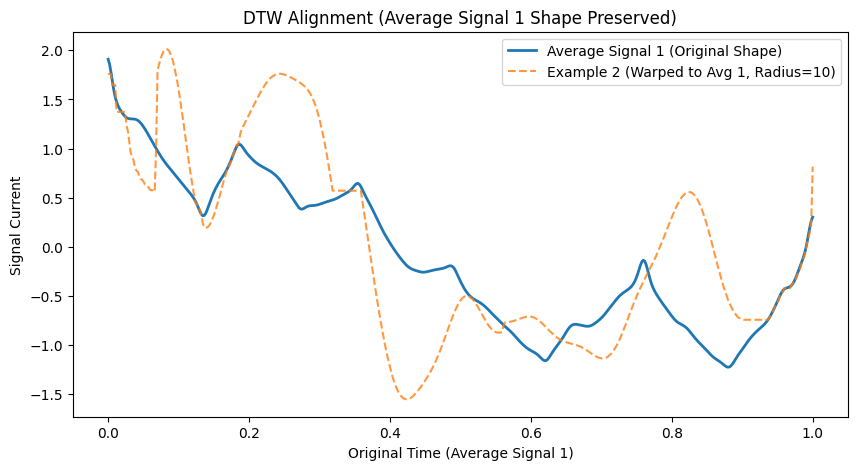

In [25]:
from scipy.signal import resample

average_signal_1_df=pd.DataFrame(np.array([np.linspace(0,1,500),gaussian_filter1d(average_signal_1,sigma=2.5)]).T,columns=['t','i'])
np_example_2 = example_2.to_numpy()
np_average_signal_1 = average_signal_1_df.to_numpy()
time_avg_1 = np_average_signal_1[:, 0]
signal_avg_1 = np_average_signal_1[:, 1]
signal_example_2 = np_example_2[:, 1]


signal_example_2_resampled = resample(signal_example_2, len(signal_avg_1))


radius_value = 10
dpath, _ = dtw_path(signal_example_2_resampled, signal_avg_1, 
                    global_constraint='sakoe_chiba', 
                    sakoe_chiba_radius=radius_value)


warped_example_2 = np.zeros_like(signal_avg_1)


for j in range(len(signal_avg_1)):

    matching_idx1 = [idx1 for idx1, idx2 in dpath if idx2 == j]
    

    if matching_idx1:
        warped_example_2[j] = np.mean(signal_example_2_resampled[matching_idx1])


plt.figure(figsize=(10, 5))

plt.plot(time_avg_1, signal_avg_1, label="Average Signal 1 (Original Shape)", linewidth=2)


plt.plot(time_avg_1, warped_example_2, label=f"Example 2 (Warped to Avg 1, Radius={radius_value})", linestyle='--', alpha=0.8)

plt.legend()
plt.title("DTW Alignment (Average Signal 1 Shape Preserved)")
plt.xlabel("Original Time (Average Signal 1)")
plt.ylabel("Signal Current")
plt.show()

In [26]:
#export_data([aligned_example_1[0]],save_path=os.path.join('filtered_data','barycenter_alignment'),file_name='barycenter_to_180')

### Plot the distribution of the MSE betwee the aligned signals and the barycenter derived from Soft-DTW

(array([20., 16., 16., 12.,  2.,  6.,  3.,  1.,  0.,  1.]),
 array([0.23909629, 0.47113043, 0.70316457, 0.9351987 , 1.16723284,
        1.39926698, 1.63130112, 1.86333525, 2.09536939, 2.32740353,
        2.55943767]),
 <BarContainer object of 10 artists>)

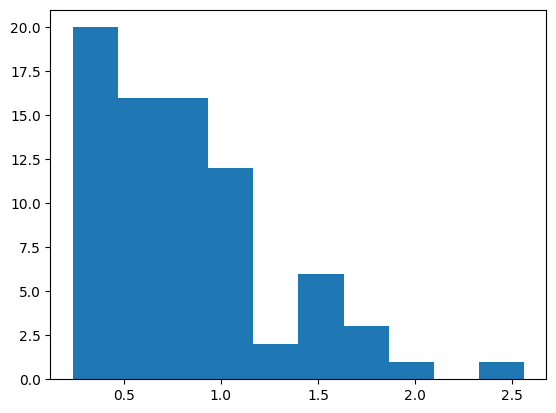

In [27]:
time_normalized_data_1_np1d=[series.iloc[:,1].to_numpy().T for series in time_normalized_data_1]

resampler=TimeSeriesResampler(sz=500)
time_normalized_data_1_np1dres=[resampler.fit_transform(series).ravel() for series in time_normalized_data_1_np1d]
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse_distribution_1=[]
for series in time_normalized_data_1_np1dres:
    mse=mean_squared_error(average_signal_1,series)
    mse_distribution_1.append(mse)
plt.hist(mse_distribution_1)

(array([ 7., 13., 15.,  5.,  2.,  4.,  6.,  1.,  1.,  1.]),
 array([0.31706713, 0.50819895, 0.69933077, 0.89046259, 1.08159441,
        1.27272623, 1.46385805, 1.65498987, 1.84612169, 2.03725351,
        2.22838533]),
 <BarContainer object of 10 artists>)

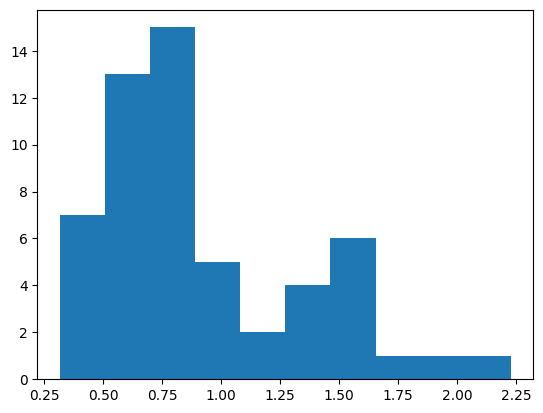

In [28]:
time_normalized_data_2_np1d = [series.iloc[:,1].to_numpy().T for series in time_normalized_data_2]

resampler = TimeSeriesResampler(sz=500)
time_normalized_data_2_np1dres = [resampler.fit_transform(series).ravel() for series in time_normalized_data_2_np1d]

from sklearn.metrics import mean_absolute_error, mean_squared_error
mse_distribution_2 = []
for series in time_normalized_data_2_np1dres:
    mse = mean_squared_error(average_signal_2, series)
    mse_distribution_2.append(mse)
plt.hist(mse_distribution_2)

In [29]:
#export_data(np.array([selected_signal_index_1,mse_distribution_1]),save_path=os.path.join(os.getcwd(),'filtered_data','mse_distribution'),file_name='direction_1_mse')

## 4. Random Experiment Validation

To prove that the calculated Barycenter is statistically robust and not a result of overfitting or noise, we perform random validation. The dataset of a single translocation direction is randomly partitioned into three distinct subgroups. The Soft-DTW Barycenter is calculated for each subgroup independently, and the results are compared with the global barycenter. High consistency between the subgroup averages and the overall average confirms that the extracted feature is a reliable representation of the DNA translocation event.

In [30]:
import random
import math 
def random_grouping(lst, group_num=3, seed_value=42):
    group_size=math.ceil(len(lst)/group_num)
    indexed_lst = [(i, value) for i, value in enumerate(lst)]
    random.seed(seed_value)
    random.shuffle(indexed_lst)
    groups = []
    original_indices_groups = []
    for i in range(0, len(indexed_lst), group_size):
        group = indexed_lst[i:i + group_size]
        original_indices = [index for index, _ in group]
        values = [value for _, value in group]
        groups.append(values)
        original_indices_groups.append(original_indices)
    return groups, original_indices_groups

In [31]:
from tslearn.preprocessing import TimeSeriesResampler
def average_current(data,resample_length=None):   
    max_aligned_len=max([series.shape[1] for series in data])
    resampler=TimeSeriesResampler(sz=max_aligned_len if resample_length is None else resample_length)
    
    interplotation_aligned_data=[resampler.fit_transform(series[-1,:]).ravel() for series in data]

    average_current=np.sum(interplotation_aligned_data,axis=0)
    average_current/=len(interplotation_aligned_data)
    
        
    return average_current

In [32]:
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.ndimage import gaussian_filter1d

def validate_barycenter_robustness(
    time_normalized_data: List[np.ndarray],
    average_signal: np.ndarray,
    selected_signal_index: List[int],
    direction: str,
    target_path: str,
    align_path: str,
    random_times: int = 50
) -> Tuple[List[List[float]], List[List[float]]]:
    """
    Validates the robustness of Soft-DTW barycenter calculation by random partitioning.

    This function performs random validation to ensure the calculated barycenter is statistically
    robust and not a result of overfitting. The dataset is randomly partitioned into three subgroups,
    Soft-DTW barycenters are calculated for each subgroup, and results are compared with the global
    barycenter through MSE calculations and visualization.

    Args:
        time_normalized_data: List of normalized time series arrays for the translocation direction.
        average_signal: The global average signal (barycenter) for comparison.
        selected_signal_index: List of original signal indices for the direction.
        direction: String identifier for the direction ('direction_1' or 'direction_2').
        target_path: Path to save the subgroup barycenter comparison plots.
        align_path: Path to save the aligned barycenter comparison plots.

    Returns:
        A tuple containing:
        - mse_total: List of MSE lists for each seed's subgroup barycenters vs global average.
        - mse_alignment: List of MSE lists for each seed's aligned barycenters vs global average.
    """
    mse_total = []
    mse_alignment = []

    for seed in range(1, random_times + 1):
        # Random grouping into 3 subgroups
        groups, group_indices = random_grouping(time_normalized_data, group_num=3, seed_value=seed)
        original_indices = [[selected_signal_index[i] for i in series] for series in group_indices]

        # Calculate barycenters for each subgroup
        barycenter_series = []
        for series in groups:
            barycenter_series.append(barycenter_process(series))

        # Calculate MSE and plot subgroup barycenters
        mse = []
        for group_idx, series in enumerate(barycenter_series):
            mse_val = mean_squared_error(average_signal, series)
            mse.append(round(mse_val, ndigits=4))
            series_time = np.linspace(0, 1, len(series))
            plt.plot(series_time, gaussian_filter1d(series, sigma=2.5),
                    label=f'group{group_idx+1} mse{mse[group_idx]}')

        mean_mse = sum(mse) / len(mse)
        mse_total.append(mse)

        plt.plot(np.linspace(0, 1, len(average_signal)),
                gaussian_filter1d(average_signal, sigma=2.5), label='total')
        plt.title(f'{direction} seed{seed} mse_mean{mean_mse}')
        plt.legend()
        plt.savefig(os.path.join(target_path, f'{direction}seed{seed}'))
        plt.clf()

        # Prepare for DTW alignment
        soft_dtw_series = []
        for series in barycenter_series:
            series_time = np.linspace(0, 1, len(series))
            soft_dtw_series.append(pd.DataFrame({'t': series_time, 'i': series}))

        # Perform DTW alignment
        aligned_barycenter, _ = dtw_alignment(
            soft_dtw_series, signal_index=None, plot_series=True,
            plot_alignment=False, show_matrix=False, smooth=False,
            constraint="sakoe_chiba", sakoe_radius=80, target_path=None,
            inverse=False, series_standard=None
        )

        # Calculate MSE for aligned barycenters and plot
        mse_aligned = []
        for idx, series in enumerate(aligned_barycenter):
            mse_val = mean_squared_error(average_signal, series[1, :])
            mse_aligned.append(round(mse_val, ndigits=4))
            plt.plot(series[0, :], gaussian_filter1d(series[1, :], sigma=2.5),
                    label=f'group{idx+1} mse{mse_aligned[idx]}')

        mean_mse_aligned = sum(mse_aligned) / len(mse_aligned)
        mse_alignment.append(mse_aligned)

        plt.plot(np.linspace(0, 1, len(average_signal)),
                gaussian_filter1d(average_signal, sigma=2.5), label='total')
        plt.legend(fontsize=10)
        plt.savefig(os.path.join(align_path, f'{direction}seed{seed}mse{round(mean_mse_aligned, ndigits=4)}.png'))
        plt.clf()

    plt.close('all')
    return mse_total, mse_alignment

### Direction 1 Random test

### A simple visualization of the random grouping validation with seed = 1 for both Direciton 1 and Direction 2

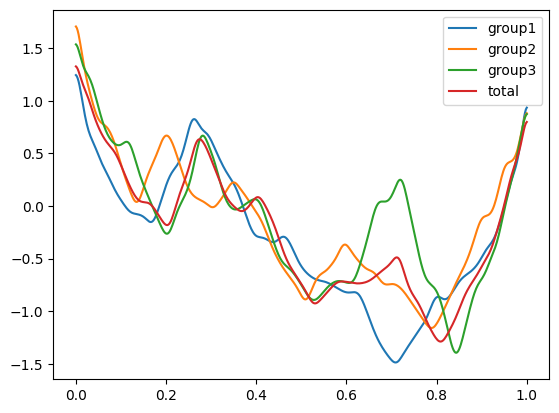

In [33]:
direction_2_groups,direction_2_index=random_grouping(time_normalized_data_2,group_num=3,seed_value=1)

barycenter_series_2=[]
for series in direction_2_groups:    
    barycenter_series_2.append(barycenter_process(series))
    
mse_2=[]

for group, series in enumerate(barycenter_series_2[:]):
    mse=mean_squared_error(average_signal_2,series)
    mse_2.append(round(mse,ndigits=4))
    
for group, series in enumerate(barycenter_series_2[:]):
    series_time=np.linspace(0,1,len(series))
    plt.plot(series_time,gaussian_filter1d(series,sigma=5),label='group'+str(group+1))
plt.plot(np.linspace(0,1,len(average_signal_2)),gaussian_filter1d(average_signal_2,sigma=5),label='total')
plt.legend()
plt.show()

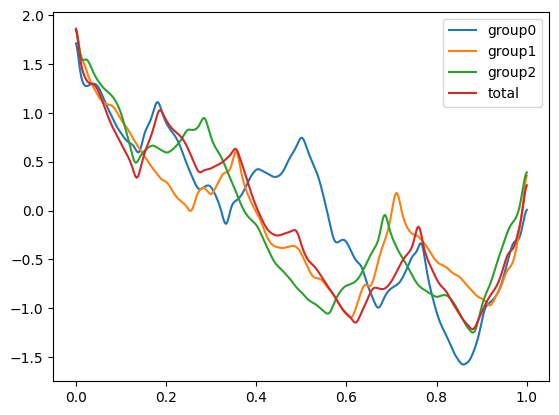

In [34]:
direction_1_groups,direction_1_index=random_grouping(time_normalized_data_1,seed_value=1)
direction_1_original_index = [[selected_signal_index_1[i] for i in series]  for series in direction_1_index]
barycenter_series_1=[]

for series in direction_1_groups:    
    barycenter_series_1.append(barycenter_process(series))
    
for group, series in enumerate(barycenter_series_1[:]):
    series_time=np.linspace(0,1,len(series))
    plt.plot(series_time,gaussian_filter1d(series,sigma=3),label='group'+str(group))
plt.plot(np.linspace(0,1,len(average_signal_1)),gaussian_filter1d(average_signal_1,sigma=3),label='total')
plt.legend()
plt.show()

### A simple visualization of alignment of the random group barycenters and the mean of the aligned random group barycenters 

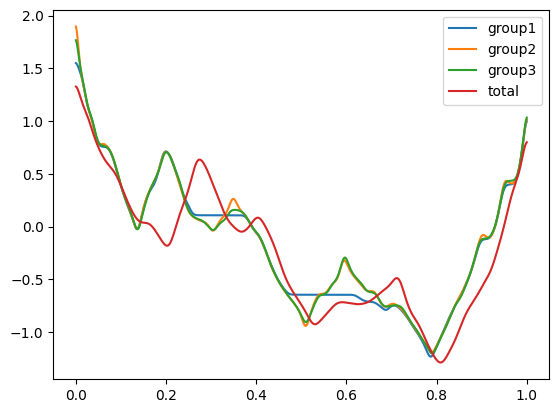

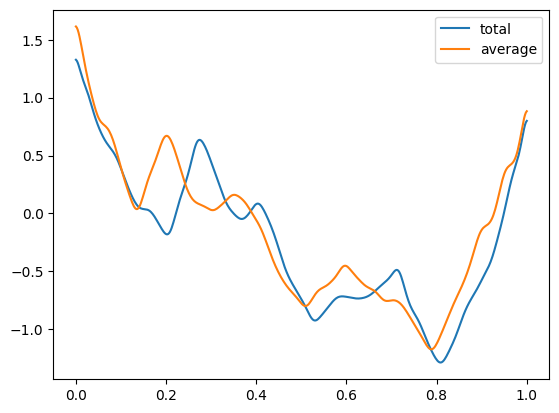

In [35]:
soft_dtw_series_2=[]
for series in barycenter_series_2:
    series_time=np.linspace(0,1,len(series))
    soft_dtw_series_2.append(pd.DataFrame({'t':series_time,'i':series}))
    
aligned_barycenter_2,_=dtw_alignment(soft_dtw_series_2,signal_index=None,plot_series=True,
                                            plot_alignment=False,show_matrix=False,smooth=False,constraint="sakoe_chiba",
                                            sakoe_radius=100,target_path=None,inverse=False)
for index, series in enumerate(aligned_barycenter_2):
            
    plt.plot(series[0,:], gaussian_filter1d(series[1,:],sigma=3),label = f'group{index+1}')

plt.plot(np.linspace(0,1,len(average_signal_2)),gaussian_filter1d(average_signal_2,sigma=5),label = 'total')
plt.legend(fontsize=10)
plt.show()

average_current_2=average_current(aligned_barycenter_2,resample_length=500)
plt.plot(np.linspace(0,1,len(average_signal_2)),gaussian_filter1d(average_signal_2,sigma=5),label = 'total')
plt.plot(np.linspace(0,1,len(average_current_2)),gaussian_filter1d(average_current_2,sigma=5),label = 'average')
plt.legend(fontsize=10)
plt.show()

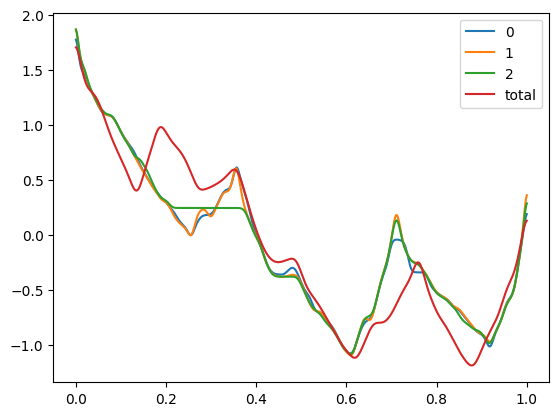

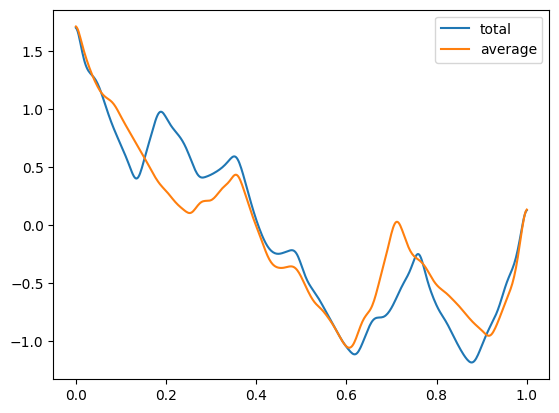

In [36]:
soft_dtw_series_1=[]
for series in barycenter_series_1:
    series_time=np.linspace(0,1,len(series))
    soft_dtw_series_1.append(pd.DataFrame({'t':series_time,'i':series}))
    
aligned_barycenter_1,_=dtw_alignment(soft_dtw_series_1,signal_index=None,plot_series=True,
                                            plot_alignment=False,show_matrix=False,smooth=False,constraint="sakoe_chiba",
                                            sakoe_radius=80,target_path=None,inverse=False)
for index, series in enumerate(aligned_barycenter_1):
            
    plt.plot(series[0,:], gaussian_filter1d(series[1,:],sigma=3),label=str(index))

plt.plot(np.linspace(0,1,len(average_signal_1)),gaussian_filter1d(average_signal_1,sigma=5),label='total')
plt.legend(fontsize=10)
plt.show()

average_current_1 = average_current(aligned_barycenter_1, resample_length=500)
plt.plot(np.linspace(0, 1, len(average_signal_1)), gaussian_filter1d(average_signal_1, sigma=5), label='total')
plt.plot(np.linspace(0, 1, len(average_current_1)), gaussian_filter1d(average_current_1, sigma=5), label='average')
plt.legend(fontsize=10)
plt.show()

### Random test for 50 seeds 
Mean squared error of the grouped signal barycenters betweeen the barycenter of all signals are calculated for 50 seeds, which will later be sorted for 10 seeds with least total mse. The figures of the 50 random tests will be saved

In [37]:
# Random validation for direction_2


mse_2_total=[]
mse_2_alignment=[]
cur_dir=os.getcwd()
target_path=os.path.join(cur_dir,'figure_final','test_figure','direction_2')
align_path=os.path.join(cur_dir,'figure_final','alignment_figure','direction_2')

mse_2_total, mse_2_alignment = validate_barycenter_robustness(
    time_normalized_data_2,
    average_signal_2,
    selected_signal_index_2,
    'direction_2',
    target_path,
    align_path
)




KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [ ]:
# Random validation for direction_1


mse_1_total=[]
mse_1_alignment=[]
cur_dir=os.getcwd()
target_path=os.path.join(cur_dir,'figure_final','test_figure','direction_1')
align_path=os.path.join(cur_dir,'figure_final','alignment_figure','direction_1')

mse_1_total, mse_1_alignment = validate_barycenter_robustness(
    time_normalized_data_1,
    average_signal_1,
    selected_signal_index_1,
    'direction_1',
    target_path,
    align_path
)

### Select the 10 least MSE random seeds and save to data to Excel files

In [ ]:
# Exporting barycenter results for direction_2 with selected random seeds
for seed in (7,14,20,23,27,35,36,37,41,48):
    direction_2_groups,direction_2_index=random_grouping(time_normalized_data_2,group_num=3,seed_value=seed)
    direction_2_original_index = [[selected_signal_index_2[i] for i in series] for series in direction_2_index]
    barycenter_series_2=[]
    barycenter_series_export=[]
    for series in direction_2_groups:
        series=barycenter_process(series)    
        barycenter_series_2.append(series)
        barycenter_series_export.append(gaussian_filter1d(series,sigma=2.5).ravel())
    barycenter_series_export.append(average_signal_2_export.ravel())
    export_data(barycenter_series_export,save_path=os.path.join('final_export_data','random_group_barycenter','direction_2'),file_name='direction_2'+'seed'+str(seed))
    soft_dtw_series_2=[]
    for series in barycenter_series_2:
        series_time=np.linspace(0,1,len(series))
        soft_dtw_series_2.append(pd.DataFrame({'t':series_time,'i':series}))
    aligned_barycenter_2,_=dtw_alignment(soft_dtw_series_2,signal_index=None,plot_series=True,
                                        plot_alignment=False,show_matrix=False,smooth=False,constraint="sakoe_chiba",
                                        sakoe_radius=80,target_path=None,inverse=False,series_standard=None)
    
    aligned_barycenter_export=[gaussian_filter1d(series[-1,:],sigma=2.5).ravel() for series in aligned_barycenter_2 ]
    aligned_barycenter_export.append(average_signal_2_export.ravel())
    export_data(aligned_barycenter_export,save_path=os.path.join('final_export_data','random_group_barycenter_aligned','direction_2'),file_name='direction_2'+'seed'+str(seed))
    average_current_2 = gaussian_filter1d(average_current(aligned_barycenter_2, resample_length=500),sigma=2.5).ravel()
    av_lst=[average_current_2]
    av_lst.append(average_signal_2_export.ravel())
    export_data(av_lst,save_path=os.path.join('final_export_data','random_group_barycenter_average','direction_2'),file_name='direction_2'+'seed'+str(seed))
    
 

In [ ]:
# Random validation for direction_1 with selected seeds
for seed in (1,2,3,13,15,21,29,30,36,48):
    direction_1_groups, direction_1_index = random_grouping(time_normalized_data_1, group_num=3, seed_value=seed)
    direction_1_original_index = [[selected_signal_index_1[i] for i in series] for series in direction_1_index]
    barycenter_series_1 = []
    barycenter_series_export = []
    for series in direction_1_groups:
        series = barycenter_process(series)
        barycenter_series_1.append(series)
        barycenter_series_export.append(gaussian_filter1d(series, sigma=2.5).ravel())
    barycenter_series_export.append(average_signal_1_export.ravel())
    export_data(barycenter_series_export, save_path=os.path.join('final_export_data', 'random_group_barycenter', 'direction_1'), file_name='direction_1' + 'seed' + str(seed))
    soft_dtw_series_1 = []
    for series in barycenter_series_1:
        series_time = np.linspace(0, 1, len(series))
        soft_dtw_series_1.append(pd.DataFrame({'t': series_time, 'i': series}))
    aligned_barycenter_1, _ = dtw_alignment(soft_dtw_series_1, signal_index=None, plot_series=True,
                                            plot_alignment=False, show_matrix=False, smooth=False, constraint="sakoe_chiba",
                                            sakoe_radius=80, target_path=None, inverse=False, series_standard=None)
    aligned_barycenter_export = [gaussian_filter1d(series[-1, :], sigma=2.5).ravel() for series in aligned_barycenter_1]
    aligned_barycenter_export.append(average_signal_1_export.ravel())
    export_data(aligned_barycenter_export, save_path=os.path.join('final_export_data', 'random_group_barycenter_aligned', 'direction_1'), file_name='direction_1' + 'seed' + str(seed))
    average_current_1 = gaussian_filter1d(average_current(aligned_barycenter_1, resample_length=500), sigma=2.5).ravel()
    av_lst = [average_current_1]
    av_lst.append(average_signal_1_export.ravel())
    export_data(av_lst, save_path=os.path.join('final_export_data', 'random_group_barycenter_average', 'direction_1'), file_name='direction_1' + 'seed' + str(seed))

## 5. Data Export

This section exports the processed data, aligned signals, barycenters, and analysis results to Excel files for further use or reporting.

In [ ]:
direction_1_export=[]
for series in barycenter_series_2:
    series_time=np.linspace(0,1,len(series))
    processed_current=gaussian_filter1d(series,sigma=3)
    direction_1_export.append(pd.DataFrame({'t':series_time,'i':processed_current}))
series_time=np.linspace(0,1,len(average_signal_2))
direction_1_export.append(pd.DataFrame({'t':series_time,'i':gaussian_filter1d(average_signal_2,sigma=3)}))
    


In [ ]:

# direction_2_aligned_export=[]
# for series in aligned_barycenter_2:
#     series_time=np.linspace(0,1,series.shape[1])
#     processed_current=gaussian_filter1d(series[1,:],sigma=3).T
#     direction_2_aligned_export.append(pd.DataFrame({'t':series_time,'i':processed_current}))
# series_time=np.linspace(0,1,len(average_signal_2))
# direction_2_aligned_export.append(pd.DataFrame({'t':series_time,'i':gaussian_filter1d(average_signal_2,sigma=3)}))

In [ ]:
# sec_path='final_export_data'
# class_path='grouped_barycenter_aligned'
# direction_path='direction_2'
# export_data(direction_2_aligned_export,save_path=os.path.join(sec_path,class_path,direction_path),file_name='grouped_barycenter_aligned_2')

Export Data

In [ ]:
# export_data(aligned_data_1_filtered,save_path=os.path.join('final_export_data','data_alignment'),file_name='direction_1_1',signal_index=selected_signal_index_1)
# export_data(aligned_data_2_filtered,save_path=os.path.join('final_export_data','data_alignment'),file_name='direction_2_2',signal_index=selected_signal_index_2)

In [ ]:
# export_data(time_normalized_data_1,save_path=os.path.join('final_export_data','data_alignment'),file_name='direction_1_processed',signal_index=selected_signal_index_1)
# export_data(time_normalized_data_2,save_path=os.path.join('final_export_data','data_alignment'),file_name='direction_2_processed',signal_index=selected_signal_index_2)
